### Setup

In [1]:
import os
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from glob import glob

### Scatterplot

In [2]:
df = pd.read_csv('full_pipelines_vs_postagg.tsv', sep='\t')
df = df.fillna(0)
df = df.loc[(df.comb_acc_f1 > 0)|(df.comb_acc_f2 > 0)]
df['gene_type2'] = df['gene_type'].apply(lambda x: 'SeqSim>0.99' if x in ['type_1', 'type_3'] else 'SeqSim<0.99')
df

,gene_type,gene,refcn,num_exon,comb_acc_f1,ref_acc_f1,nref_acc_f1,comb_acc_f2,ref_acc_f2,nref_acc_f2,gene_type2
0,type_1,AQP12A,4,3,1.0000,1.0000,1.0000,0.9881,0.9920,0.0000,SeqSim>0.99
1,type_1,C4A,4,41,0.9565,0.9874,0.9262,0.0000,0.0000,0.0000,SeqSim>0.99
2,type_1,CFC1,4,6,0.9992,0.9992,0.0000,0.7538,0.9214,0.0434,SeqSim>0.99
3,type_1,CHRNA7,4,6,0.9997,1.0000,0.9982,0.0000,0.0000,0.0000,SeqSim>0.99
4,type_1,CTRB1,4,5,0.9630,0.9801,0.8491,0.9439,0.9675,0.7879,SeqSim>0.99
...,...,...,...,...,...,...,...,...,...,...,...
117,type_split,DDX11_refcn4,4,1,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,SeqSim<0.99
118,type_split,DDX11_refcn6,6,25,0.9971,1.0000,0.3000,0.0000,0.0000,0.0000,SeqSim<0.99
119,type_split,EMB_refcn4,4,6,0.9996,1.0000,0.9444,0.0000,0.0000,0.0000,SeqSim<0.99
120,type_split,EMB_refcn6,6,1,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,SeqSim<0.99


In [24]:
# Save the dataframe above to a TSV file
# df.to_csv('preagg_vs_postagg.tsv', sep='\t', index=None, float_format='%.4f')

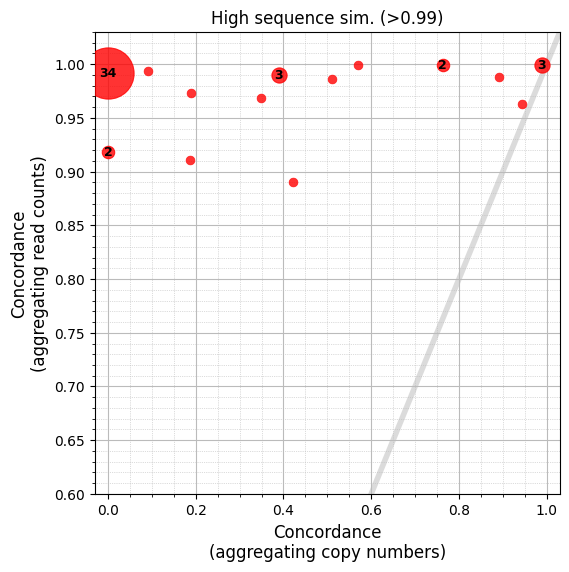

In [25]:
from sklearn.cluster import DBSCAN

# ===================================================================
# Add any genes to exclude from analysis
exclude = ['GTF2I']
df2 = df.loc[~df.gene.isin(exclude)]

# ===================================================================
# Cluster points based on radius = EPS_VAL

sub = df2.loc[
    df2.gene_type.isin(['type_1','type_3','type_split']), 
    ['comb_acc_f2', 'comb_acc_f1']
].copy().to_numpy()

EPS_VAL = 0.02
clustering = DBSCAN(eps=EPS_VAL, min_samples=1).fit(sub)
labels = clustering.labels_

# ===================================================================
# For each cluster, compute centroid & size
unique_labels = np.unique(labels)
cluster_points = []

for lbl in unique_labels:
    pts = sub[labels == lbl]
    count = pts.shape[0]
    centroid = pts.mean(axis=0)
    cluster_points.append((centroid[0], centroid[1], count))

# =================================================================== 
# Visualization
plt.figure(figsize=(6, 6)) # add dpi=300 for higher resolution
p_color = 'red'

for x, y, count in cluster_points:
    if count == 1:
        # Normal point
        ax = plt.scatter(x, y,
                         color=p_color, 
                         s=40, 
                         alpha=0.8,
                         linewidth=0.5, 
                         zorder=100)
    else:
        # Larger point proportional to count
        ax = plt.scatter(x, y,
                         color=p_color,
                         s=40*count, # scale size
                         alpha=0.8,
                         linewidth=0.8,
                         zorder=100)

        # Add count annotation at center
        plt.text(x, y, str(count),
                 color='black', 
                 fontsize=9,
                 fontweight='bold',
                 ha='center', 
                 va='center',
                 zorder=200)

# Identity 1-to-1 gray line
plt.axline((0, 0), slope=1, color='lightgray',
           linestyle='-', linewidth=4, alpha=0.8, zorder=-1)

# Formatting
plt.grid(which='major', color='#BBBBBB', linewidth=0.8, zorder=-1)
plt.grid(which='minor', color='#BBBBBB', linestyle=':', linewidth=0.5, zorder=-1)
plt.minorticks_on()

plt.title('High sequence sim. (>0.99)', fontsize=12)
plt.xlim(-0.03, 1.03)
plt.ylim(0.6, 1.03)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel('Concordance\n(aggregating copy numbers)', fontsize=12)
plt.ylabel('Concordance\n(aggregating read counts)', fontsize=12)

plt.show()

In [35]:
# High sequence genes coordinates for the above
# df2.loc[df2.gene_type2=='SeqSim>0.99'].sort_values(by=['comb_acc_f1','comb_acc_f2'])[['gene_type','gene','comb_acc_f1','comb_acc_f2']]

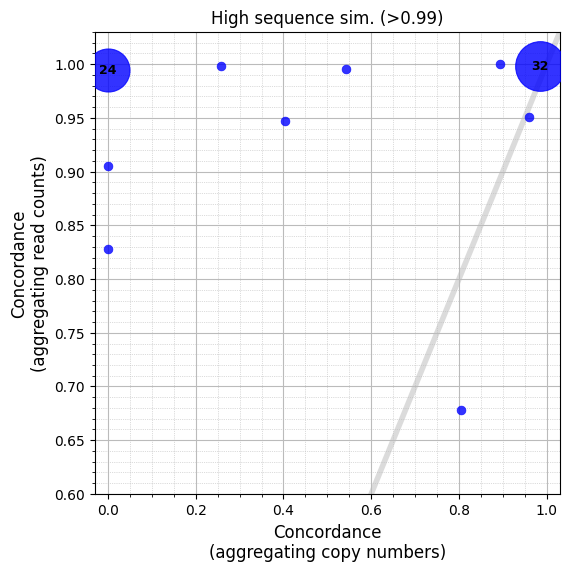

In [26]:
from sklearn.cluster import DBSCAN

# ===================================================================
# Add any genes to exclude from analysis
exclude = ['GTF2I']
df2 = df.loc[~df.gene.isin(exclude)]

# ===================================================================
# Cluster points based on radius = EPS_VAL

sub = df.loc[
    df.gene_type.isin(['type_2', 'type_4']), 
    ['comb_acc_f2', 'comb_acc_f1']
].copy().to_numpy()

EPS_VAL = 0.02
clustering = DBSCAN(eps=EPS_VAL, min_samples=1).fit(sub)
labels = clustering.labels_

# ===================================================================
# For each cluster, compute centroid & size
unique_labels = np.unique(labels)
cluster_points = []

for lbl in unique_labels:
    pts = sub[labels == lbl]
    count = pts.shape[0]
    centroid = pts.mean(axis=0)
    cluster_points.append((centroid[0], centroid[1], count))

# =================================================================== 
# Visualization
plt.figure(figsize=(6, 6)) # add dpi=300 for higher resolution
p_color = 'blue'

for x, y, count in cluster_points:
    if count == 1:
        # Normal point
        ax = plt.scatter(x, y,
                         color=p_color, 
                         s=40, 
                         alpha=0.8,
                         linewidth=0.5, 
                         zorder=100)
    else:
        # Larger point proportional to count
        ax = plt.scatter(x, y,
                         color=p_color,
                         s=40*count, # scale size
                         alpha=0.8,
                         linewidth=0.8,
                         zorder=100)

        # Add count annotation at center
        plt.text(x, y, str(count),
                 color='black', 
                 fontsize=9,
                 fontweight='bold',
                 ha='center', 
                 va='center',
                 zorder=200)

# Identity 1-to-1 gray line
plt.axline((0, 0), slope=1, color='lightgray',
           linestyle='-', linewidth=4, alpha=0.8, zorder=-1)

# Formatting
plt.grid(which='major', color='#BBBBBB', linewidth=0.8, zorder=-1)
plt.grid(which='minor', color='#BBBBBB', linestyle=':', linewidth=0.5, zorder=-1)
plt.minorticks_on()

plt.title('High sequence sim. (>0.99)', fontsize=12)
plt.xlim(-0.03, 1.03)
plt.ylim(0.6, 1.03)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel('Concordance\n(aggregating copy numbers)', fontsize=12)
plt.ylabel('Concordance\n(aggregating read counts)', fontsize=12)

plt.show()

In [37]:
# High sequence genes coordinates for the above
# df2.loc[df2.gene_type2=='SeqSim<0.99'].sort_values(by=['comb_acc_f1','comb_acc_f2'])[['gene_type','gene','comb_acc_f1','comb_acc_f2']]

### Histogram

In [65]:
exclude = ['ORM1','GTF2I']

df = pd.read_csv('full_pipelines_vs_postagg.tsv', sep='\t')
df = df.fillna(-1)
df = df.loc[(df.comb_acc_f1 >= 0)|(df.comb_acc_f2 >= 0)]
df = df.loc[~df.gene.isin(exclude)]
df['gene_type2'] = df['gene_type'].apply(lambda x: 'SeqSim>0.99' if x in ['type_1', 'type_3'] else 'SeqSim<0.99')
df.rename(columns={'comb_acc_f1':'preagg_conc', 
                   'comb_acc_f2':'postagg_conc'}, inplace=True)
df

,gene_type,gene,refcn,num_exon,preagg_conc,ref_acc_f1,nref_acc_f1,postagg_conc,ref_acc_f2,nref_acc_f2,gene_type2
0,type_1,AQP12A,4,3,1.0000,1.0000,1.0000,0.9881,0.9920,0.0000,SeqSim>0.99
1,type_1,C4A,4,41,0.9565,0.9874,0.9262,-1.0000,-1.0000,-1.0000,SeqSim>0.99
2,type_1,CFC1,4,6,0.9992,0.9992,-1.0000,0.7538,0.9214,0.0434,SeqSim>0.99
3,type_1,CHRNA7,4,6,0.9997,1.0000,0.9982,-1.0000,-1.0000,-1.0000,SeqSim>0.99
4,type_1,CTRB1,4,5,0.9630,0.9801,0.8491,0.9439,0.9675,0.7879,SeqSim>0.99
...,...,...,...,...,...,...,...,...,...,...,...
117,type_split,DDX11_refcn4,4,1,1.0000,-1.0000,1.0000,-1.0000,-1.0000,-1.0000,SeqSim<0.99
118,type_split,DDX11_refcn6,6,25,0.9971,1.0000,0.3000,-1.0000,-1.0000,-1.0000,SeqSim<0.99
119,type_split,EMB_refcn4,4,6,0.9996,1.0000,0.9444,-1.0000,-1.0000,-1.0000,SeqSim<0.99
120,type_split,EMB_refcn6,6,1,1.0000,1.0000,-1.0000,-1.0000,-1.0000,-1.0000,SeqSim<0.99


In [70]:
# Melt dataframe
df2 = df[['gene','preagg_conc','postagg_conc',]].copy()
df2 = df2.melt('gene', var_name='prepost', value_name='comb_conc')
df2

,gene,prepost,comb_conc
0,AQP12A,preagg_conc,1.0000
1,C4A,preagg_conc,0.9565
2,CFC1,preagg_conc,0.9992
3,CHRNA7,preagg_conc,0.9997
4,CTRB1,preagg_conc,0.9630
...,...,...,...
227,DDX11_refcn4,postagg_conc,-1.0000
228,DDX11_refcn6,postagg_conc,-1.0000
229,EMB_refcn4,postagg_conc,-1.0000
230,EMB_refcn6,postagg_conc,-1.0000


In [67]:
def categorize(c):
    if c < 0.0:
        return "NA"
    if c < 0.50:
        return "0 <= c < 0.50"
    elif c < 0.80:
        return "0.50 <= c < 0.80"
    elif c < 0.90:
        return "0.80 <= c < 0.90"
    elif c < 0.95:
        return "0.90 <= c < 0.95"
    elif c < 0.98:
        return "0.95 <= c < 0.98"
    elif c < 0.99:
        return "0.98 <= c < 0.99"
    else:
        return "0.99 <= c < 1.00"
    
df2['my_bin'] = df2['comb_conc'].apply(lambda x: categorize(x))
df2

,gene,prepost,comb_conc,my_bin
0,AQP12A,preagg_conc,1.0000,0.99 <= c < 1.00
1,C4A,preagg_conc,0.9565,0.95 <= c < 0.98
2,CFC1,preagg_conc,0.9992,0.99 <= c < 1.00
3,CHRNA7,preagg_conc,0.9997,0.99 <= c < 1.00
4,CTRB1,preagg_conc,0.9630,0.95 <= c < 0.98
...,...,...,...,...
227,DDX11_refcn4,postagg_conc,-1.0000,NA
228,DDX11_refcn6,postagg_conc,-1.0000,NA
229,EMB_refcn4,postagg_conc,-1.0000,NA
230,EMB_refcn6,postagg_conc,-1.0000,NA


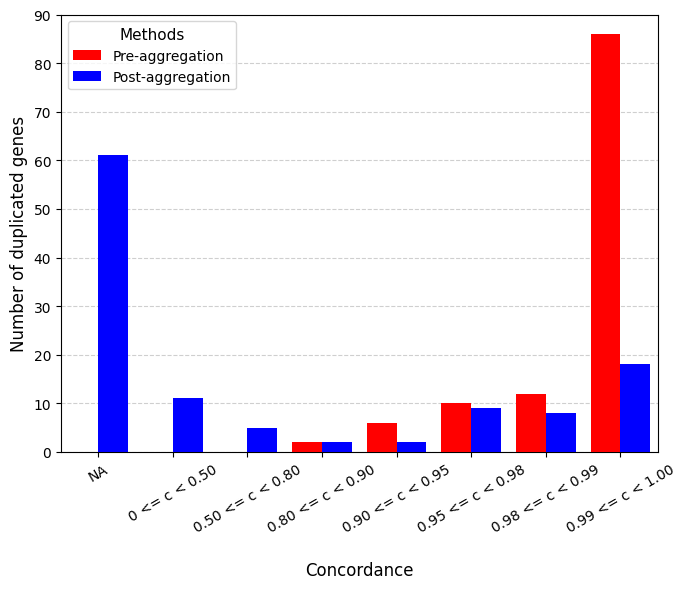

In [60]:
plt.figure(figsize=(7,6))

order = [
    "NA",
    "0 <= c < 0.50",
    "0.50 <= c < 0.80",
    "0.80 <= c < 0.90",
    "0.90 <= c < 0.95",
    "0.95 <= c < 0.98",
    "0.98 <= c < 0.99",
    "0.99 <= c < 1.00",
]

ax = sns.countplot(
    data=df2,
    x='my_bin',
    hue='prepost',
    order=order,
    # palette='Set1', 
    palette=['red','blue'], 
    saturation=1, 
    zorder=100
)

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.xlabel('\nConcordance', fontsize=12)
plt.ylabel('Number of duplicated genes', fontsize=12)
plt.xticks(rotation=30, ha='center')
plt.legend(
    title="Methods",
    labels=["Pre-aggregation", "Post-aggregation"],   # your custom names
    loc="upper left",
    frameon=True,
    fontsize=10,
    title_fontsize=11
)

plt.ylim(0,90)
plt.tight_layout()
plt.show()

In [69]:
# Check actual number in each bin
df2.groupby('prepost')['my_bin'].value_counts()

prepost       my_bin          
postagg_conc  NA                  61
              0.99 <= c < 1.00    18
              0 <= c < 0.50       11
              0.95 <= c < 0.98     9
              0.98 <= c < 0.99     8
              0.50 <= c < 0.80     5
              0.80 <= c < 0.90     2
              0.90 <= c < 0.95     2
preagg_conc   0.99 <= c < 1.00    86
              0.98 <= c < 0.99    12
              0.95 <= c < 0.98    10
              0.90 <= c < 0.95     6
              0.80 <= c < 0.90     2
Name: count, dtype: int64

In [50]:
# Check number of genes
df2['prepost'].value_counts()

prepost
preagg_conc     116
postagg_conc    116
Name: count, dtype: int64

/tmp/ipykernel_5612/2498482912.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Pre-aggregation", "Post-aggregation"])


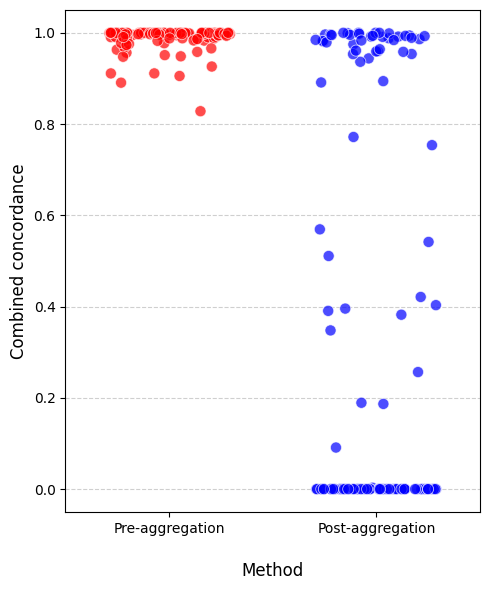

In [49]:
plt.figure(figsize=(5, 6))

ax = sns.stripplot(
    df2,
    x='prepost', 
    y='comb_conc',
    size=8,
    hue='prepost',
    palette=['red', 'blue'],
    alpha=0.7,
    edgecolor='white', linewidth=0.6,
    jitter=0.3
)
ax.set_xticklabels(["Pre-aggregation", "Post-aggregation"])

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xlabel('\nMethod', fontsize=12)
plt.ylabel('Combined concordance', fontsize=12)
plt.tight_layout()
plt.show()